# Telstra Network Disruptions - understanding the data

Before building any predictive model, we need to understand the disruption data and, crucially, **where the predictive signal lives**. This notebook explores the data directly in Neo4j - every chart is driven by a query against the graph (events, locations, log-features, alarm severities, and the fault cascade between sites), so what we see reflects how the business actually relates these entities, not just flat spreadsheets.

We work through nine questions an operations team would want answered:

1. **How big is the data, and how is it connected?**
2. **What are we predicting?** - the distribution of fault severity
3. **Does the alarm level already tell us the answer?**
4. **Which locations carry the volume, and which carry the risk?**
5. **Which log-feature codes flag severe faults?**
6. **Which resource and event types are most associated with severe faults?**
7. **How do events cluster across the network?**
8. **Does the way faults cascade between sites carry any risk signal?** - the key test for whether a graph model is worth building
9. **A visual look** at one busy, fault-prone location

In [1]:
# Setup
from dotenv import load_dotenv
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from neo4j_analysis import Neo4jAnalysis

load_dotenv()
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

graph = Neo4jAnalysis(
    os.getenv("NEO4J_URI"),
    os.getenv("NEO4J_USERNAME"),
    os.getenv("NEO4J_PASSWORD"),
    os.getenv("NEO4J_DATABASE"),
)
RENDERINGS_DIR = os.getenv("RENDERINGS_DIR", "renderings")
os.makedirs(RENDERINGS_DIR, exist_ok=True)

assert graph.verify_connection(), "Could not connect to Neo4j - run loader.ipynb first"
print("Connected.")

Connected.


## The graph schema

The loaded graph has the following schema.

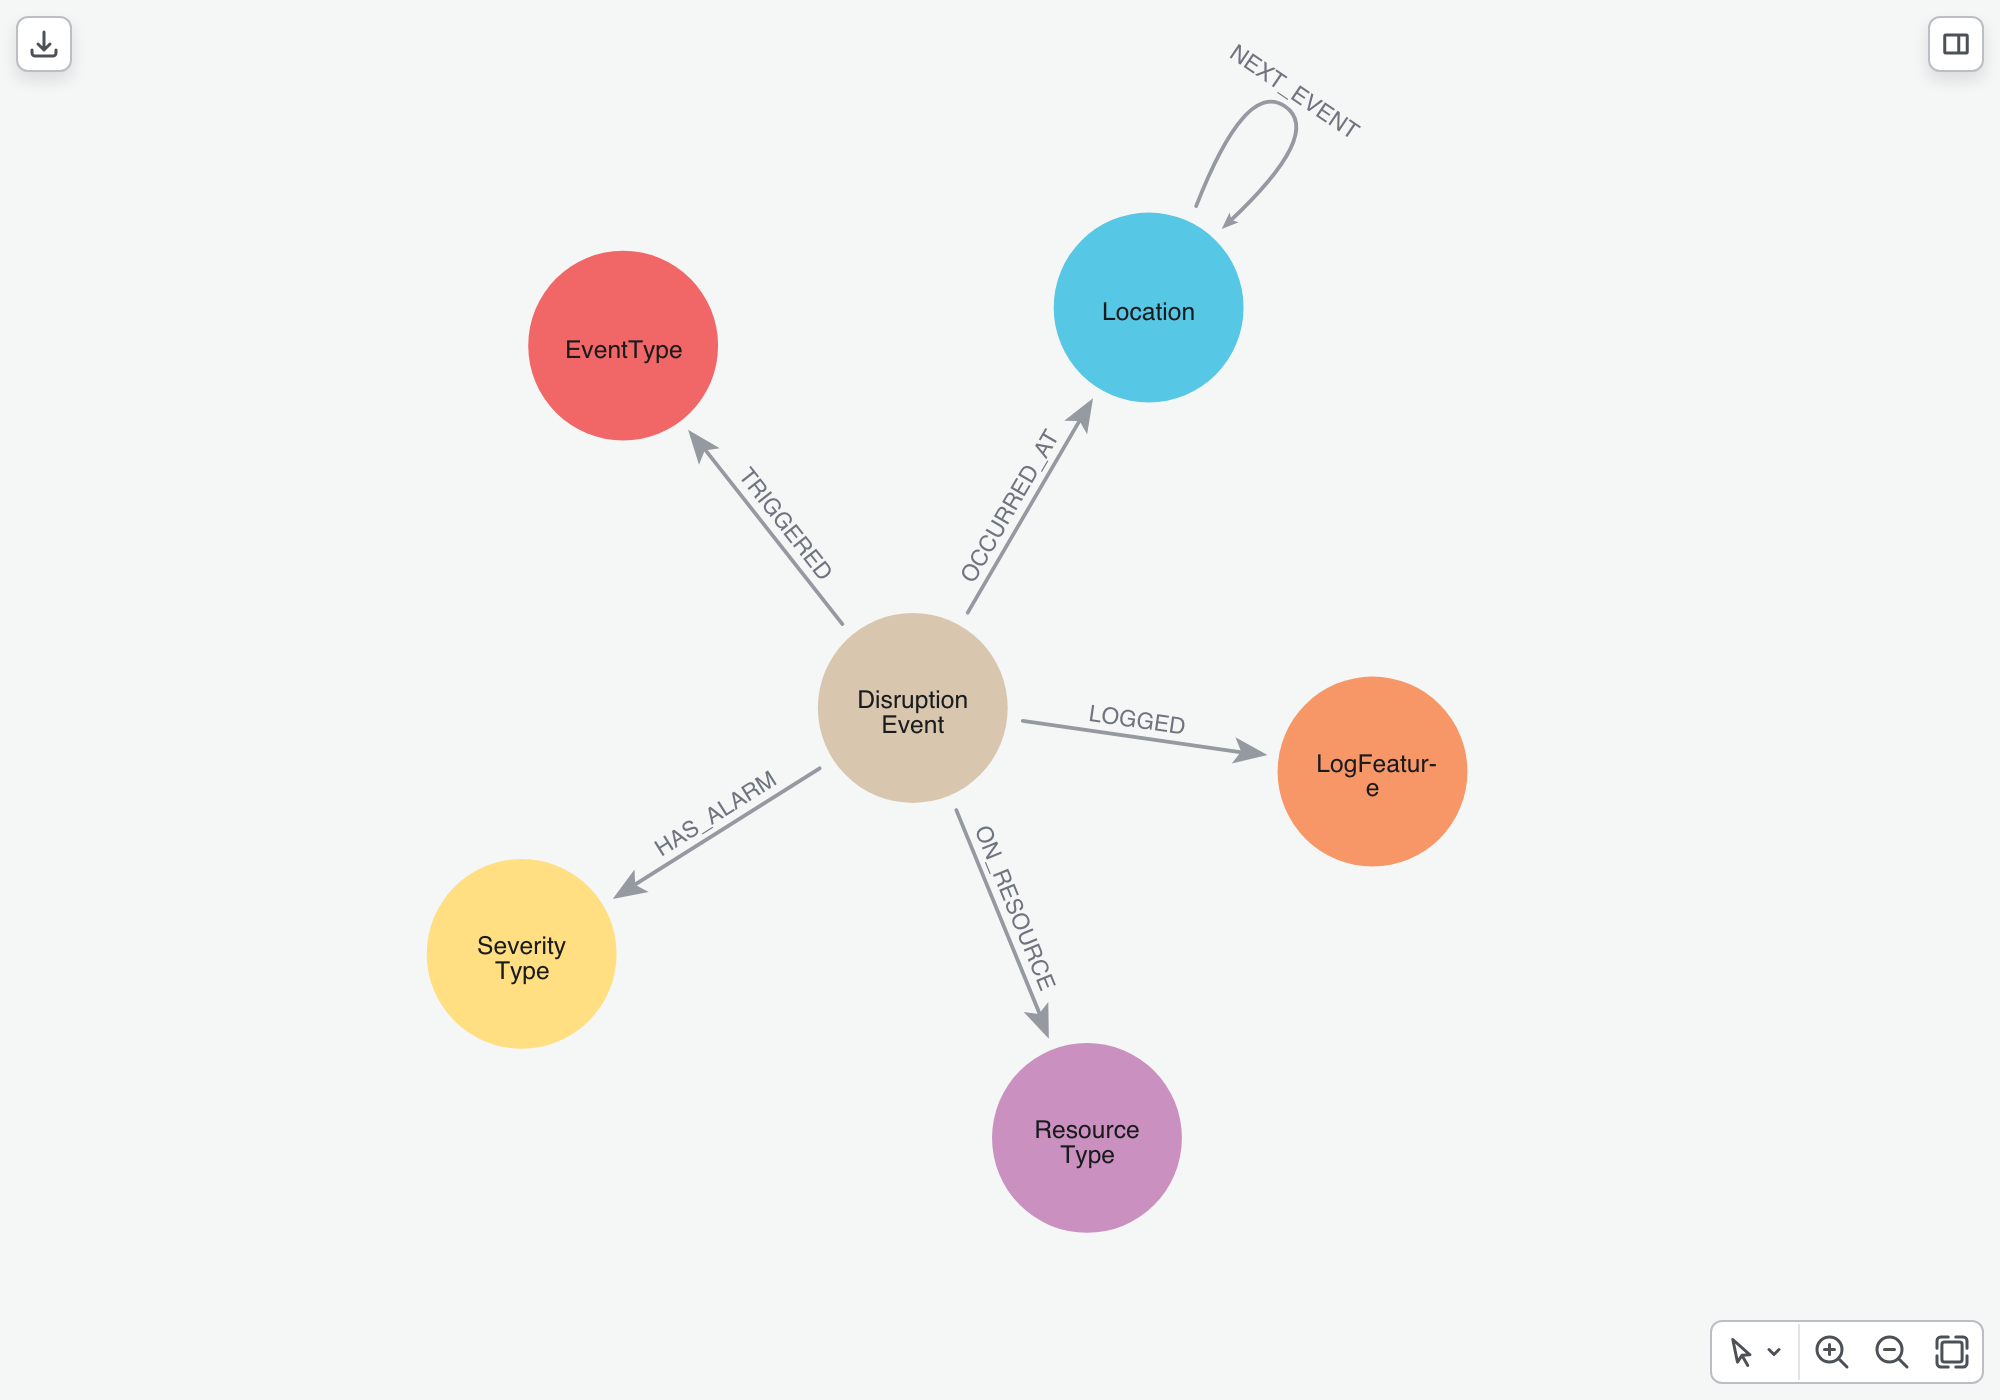

In [2]:
from neo4j_viz.neo4j import from_neo4j
from IPython.display import Image

schema = graph.run_query_viz(
    """
    CALL db.schema.visualization
    """
)

VG = from_neo4j(schema)

html = VG.render(layout="forcedirected", height="700px")
await graph.capture_graph_to_png(html, f"{RENDERINGS_DIR}/schema.png", width=1000, height=700)
Image(f"{RENDERINGS_DIR}/schema.png")



## How big is the data, and how is it connected?

A quick census of what's in the graph. The relationship counts reflect how the business records each disruption: every event has exactly one alarm and one location, but can touch many log-features, event types and resource types.

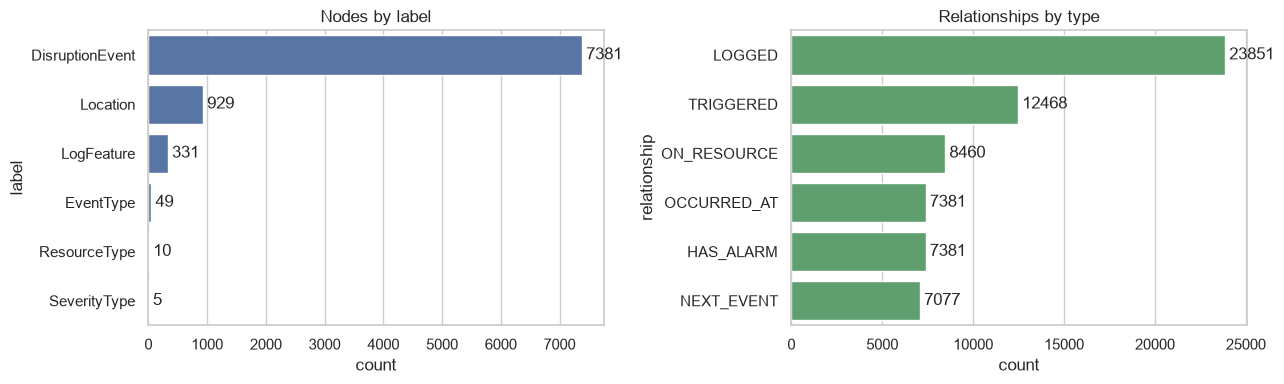

,label,count
0,DisruptionEvent,7381
1,Location,929
2,LogFeature,331
3,EventType,49
4,ResourceType,10
5,SeverityType,5


,relationship,count
0,LOGGED,23851
1,TRIGGERED,12468
2,ON_RESOURCE,8460
3,OCCURRED_AT,7381
4,HAS_ALARM,7381
5,NEXT_EVENT,7077


In [3]:
nodes = graph.run_query_df(
    "MATCH (n) UNWIND labels(n) AS label "
    "RETURN label, count(*) AS count ORDER BY count DESC"
)
rels = graph.run_query_df(
    "MATCH ()-[r]->() RETURN type(r) AS relationship, count(*) AS count ORDER BY count DESC"
)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=nodes, y="label", x="count", ax=ax[0], color="#4C72B0")
ax[0].set_title("Nodes by label")
sns.barplot(data=rels, y="relationship", x="count", ax=ax[1], color="#55A868")
ax[1].set_title("Relationships by type")
for a in ax:
    a.bar_label(a.containers[0], fmt="%d", padding=3)
plt.tight_layout()
fig.savefig(f"{RENDERINGS_DIR}/nodes_and_relationships.png", dpi=300)
plt.show()
display(nodes); display(rels)

## What are we predicting?

The outcome is **fault severity**, recorded only for historical events: `0` = no reported fault, `1` = a few, `2` = many. The classes are heavily imbalanced - about two-thirds of events are "none" - which means a model that simply guesses "none" every time would look deceptively accurate. Both the model and the way we score it have to account for this imbalance.

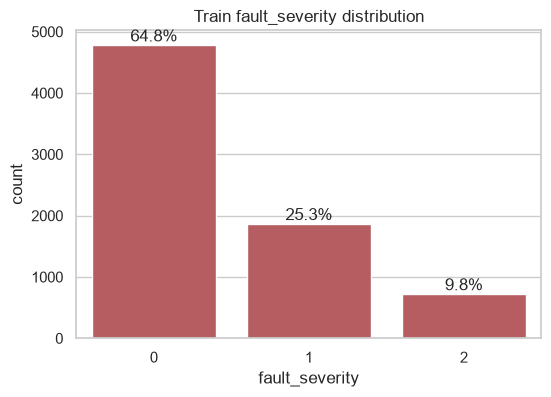

,fault_severity,count,pct
0,0,4784,64.815
1,1,1871,25.349
2,2,726,9.836


In [4]:
target = graph.run_query_df('''
    MATCH (e:DisruptionEvent {dataset:'train'})
    RETURN e.fault_severity AS fault_severity, count(*) AS count
    ORDER BY fault_severity
''')
target["pct"] = 100 * target["count"] / target["count"].sum()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=target, x="fault_severity", y="count", ax=ax, color="#C44E52")
ax.bar_label(ax.containers[0], labels=[f"{p:.1f}%" for p in target["pct"]])
ax.set_title("Train fault_severity distribution")
plt.show()
fig.savefig(f"{RENDERINGS_DIR}/fault_severity_distribution.png", dpi=300)
display(target)

## Does the alarm level already tell us the answer?

A natural first question: is the **alarm level** raised when the event fired already a good predictor of how bad the fault turns out to be? It's an early warning signal, *not* the outcome. Comparing the two side by side shows that some alarm levels do skew towards severe faults - but no single level cleanly separates serious faults from harmless ones, so the alarm alone isn't enough.

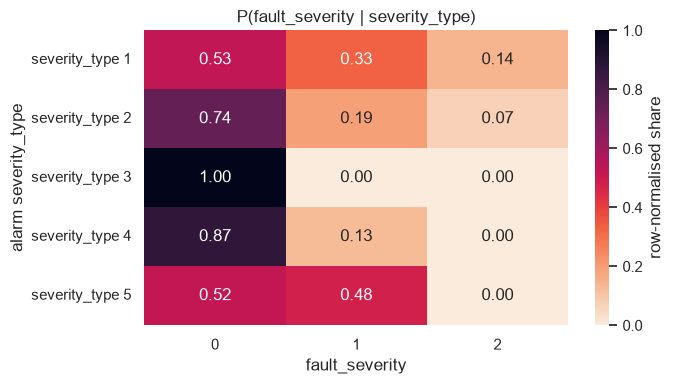

fault_severity,0,1,2,events
severity_type,,,,
severity_type 1,1778,1117,480,3375
severity_type 2,2652,693,246,3591
severity_type 3,4,0,0,4
severity_type 4,338,50,0,388
severity_type 5,12,11,0,23


In [5]:
sev = graph.run_query_df('''
    MATCH (e:DisruptionEvent {dataset:'train'})-[:HAS_ALARM]->(s:SeverityType)
    RETURN s.name AS severity_type, e.fault_severity AS fault_severity, count(*) AS count
''')
pivot = (sev.pivot_table(index="severity_type", columns="fault_severity",
                         values="count", aggfunc="sum", fill_value=0)
            .sort_index())
prop = pivot.div(pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(prop, annot=True, fmt=".2f", cmap="rocket_r", ax=ax,
            cbar_kws={"label": "row-normalised share"})
ax.set_title("P(fault_severity | severity_type)")
ax.set_xlabel("fault_severity"); ax.set_ylabel("alarm severity_type")
plt.tight_layout(); plt.show()
fig.savefig(f"{RENDERINGS_DIR}/severity_type_fault_severity_heatmap.png", dpi=300)
display(pivot.assign(events=pivot.sum(axis=1)))

## Which locations carry the volume, and which carry the risk?

Events are spread across roughly 1,100 sites, and "busy" and "risky" are two different things. A high-traffic location can be perfectly healthy, while a quieter site can be a chronic offender. We look at both - event volume on one side, average fault severity on the other - and only trust a site's risk score once it has at least 10 historical events behind it, so we're not misled by small samples.

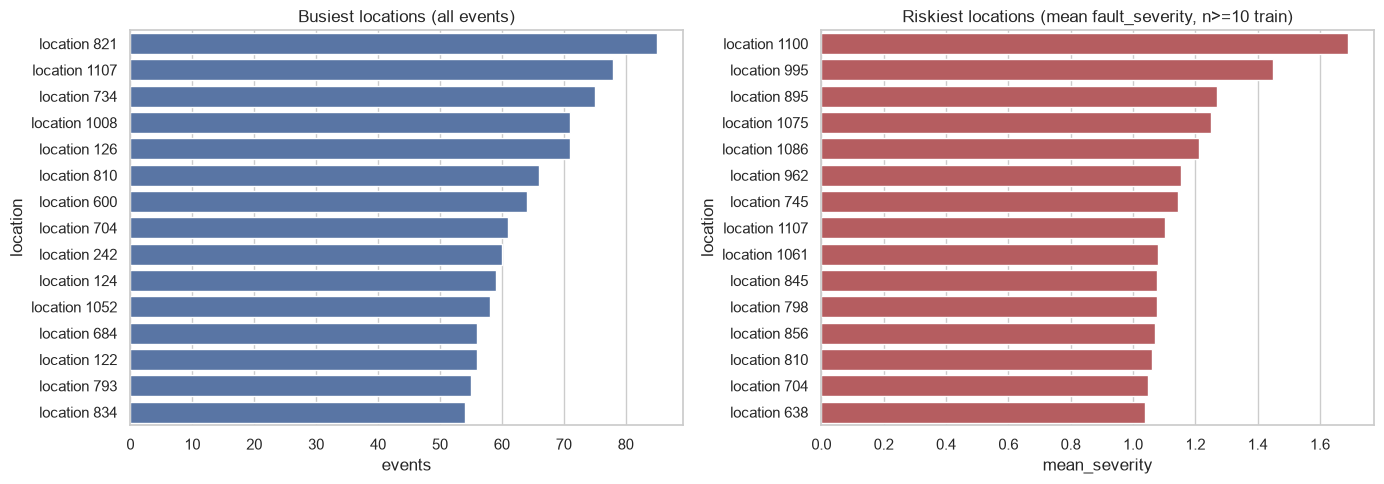

,location,n,mean_severity,pct_severe
0,location 1100,45,1.689,0.733
1,location 995,40,1.450,0.550
2,location 895,26,1.269,0.385
3,location 1075,28,1.250,0.429
4,location 1086,33,1.212,0.485
5,location 962,45,1.156,0.444
6,location 745,14,1.143,0.357
7,location 1107,78,1.103,0.423
8,location 1061,25,1.080,0.360
9,location 845,39,1.077,0.385


In [6]:
top_vol = graph.run_query_df('''
    MATCH (e:DisruptionEvent)-[:OCCURRED_AT]->(l:Location)
    RETURN l.name AS location, count(*) AS events,
           sum(CASE WHEN e.dataset='train' THEN 1 ELSE 0 END) AS train_events
    ORDER BY events DESC LIMIT 15
''')

risk = graph.run_query_df('''
    MATCH (e:DisruptionEvent {dataset:'train'})-[:OCCURRED_AT]->(l:Location)
    WITH l.name AS location, count(*) AS n,
         avg(toFloat(e.fault_severity)) AS mean_severity,
         sum(CASE WHEN e.fault_severity=2 THEN 1 ELSE 0 END)*1.0/count(*) AS pct_severe
    WHERE n >= 10
    RETURN location, n, mean_severity, pct_severe
    ORDER BY mean_severity DESC LIMIT 15
''')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=top_vol, y="location", x="events", ax=ax[0], color="#4C72B0")
ax[0].set_title("Busiest locations (all events)")
sns.barplot(data=risk, y="location", x="mean_severity", ax=ax[1], color="#C44E52")
ax[1].set_title("Riskiest locations (mean fault_severity, n>=10 train)")
plt.tight_layout(); plt.show()
fig.savefig(f"{RENDERINGS_DIR}/location_risk_and_volume.png", dpi=300)
display(risk)

## Which log-feature codes flag severe faults?

The log-feature codes are the richest signal in the data. For each code we measure two things: how often it shows up (its **support**) and the **average severity** of the events that logged it. Sorting by severity surfaces codes that act as reliable "severe-fault markers" at one end and essentially harmless ones at the other - exactly the kind of contrast a model can lean on. We also check whether the sheer **volume** of logging on an event tracks with how severe it turns out to be.

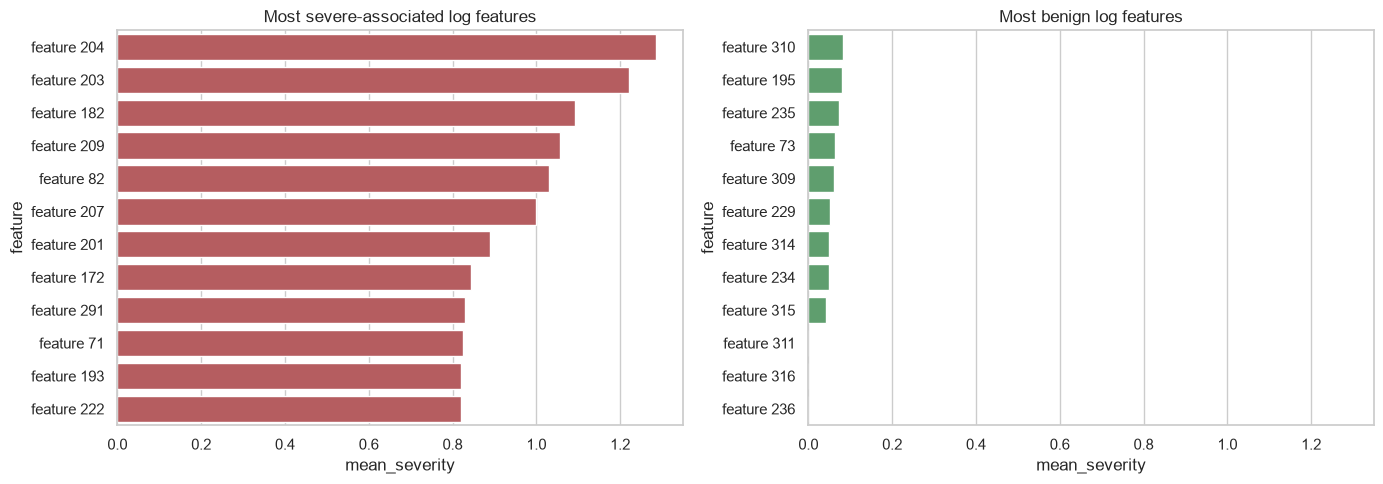

,fault_severity,avg_total_volume,avg_n_features,events
0,0,"171,932.000","15,584.000",1
1,1,"24,990.000","5,670.000",1
2,2,"37,943.000","2,597.000",1


In [7]:
feat = graph.run_query_df('''
    MATCH (e:DisruptionEvent {dataset:'train'})-[:LOGGED]->(f:LogFeature)
    WITH f.name AS feature, count(DISTINCT e) AS support,
         avg(toFloat(e.fault_severity)) AS mean_severity
    WHERE support >= 30
    RETURN feature, support, mean_severity
    ORDER BY mean_severity DESC
''')
top = feat.head(12); bottom = feat.tail(12)

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.barplot(data=top, y="feature", x="mean_severity", ax=ax[0], color="#C44E52")
ax[0].set_title("Most severe-associated log features")
sns.barplot(data=bottom, y="feature", x="mean_severity", ax=ax[1], color="#55A868")
ax[1].set_title("Most benign log features")
plt.tight_layout(); plt.show()
fig.savefig(f"{RENDERINGS_DIR}/log_feature_severity.png", dpi=300)

# Does the *total logged volume* of an event track its severity?
vol = graph.run_query_df('''
    MATCH (e:DisruptionEvent {dataset:'train'})-[r:LOGGED]->(:LogFeature)
    WITH e.fault_severity AS fault_severity, sum(r.volume) AS total_volume,
         count(r) AS n_features
    RETURN fault_severity, avg(total_volume) AS avg_total_volume,
           avg(n_features) AS avg_n_features, count(*) AS events
    ORDER BY fault_severity
''')
display(vol)

## Which resource and event types are most associated with severe faults?

These are coarser descriptors - only 10 resource types and about 50 event types. We rank each by its association with severe faults (average severity, ignoring categories with too few events to be reliable). This surfaces a handful of resource and event types that carry disproportionate risk and are worth flagging operationally.

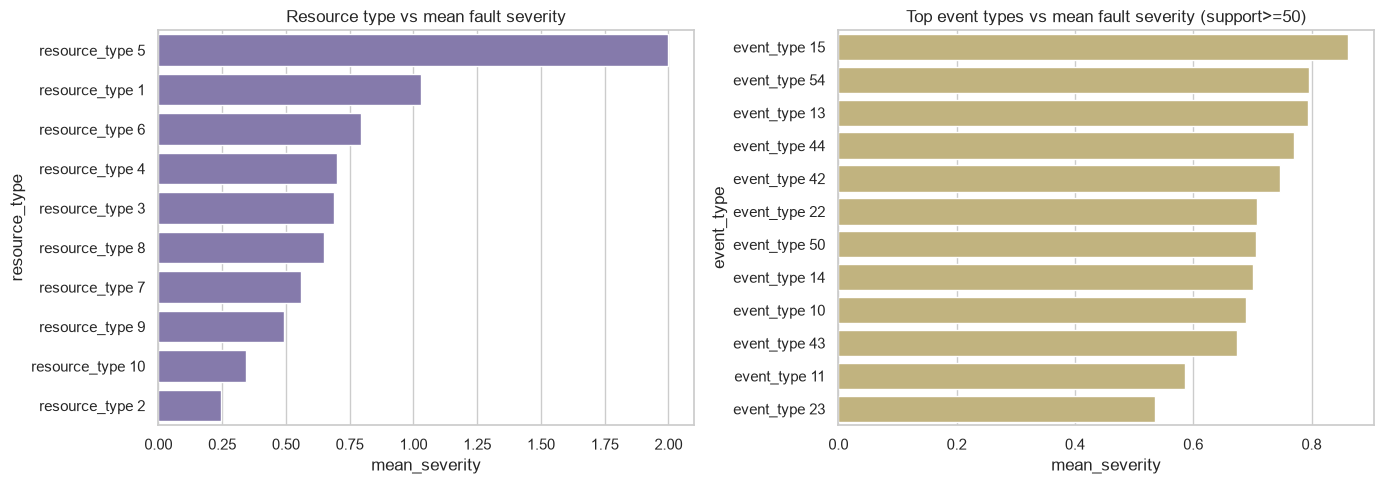

,resource_type,support,mean_severity
0,resource_type 5,4,2.000
1,resource_type 1,34,1.029
2,resource_type 6,247,0.794
3,resource_type 4,144,0.701
4,resource_type 3,58,0.690
5,resource_type 8,4051,0.650
6,resource_type 7,225,0.560
7,resource_type 9,77,0.494
8,resource_type 10,35,0.343
9,resource_type 2,3585,0.244


In [8]:
res = graph.run_query_df('''
    MATCH (e:DisruptionEvent {dataset:'train'})-[:ON_RESOURCE]->(r:ResourceType)
    WITH r.name AS resource_type, count(DISTINCT e) AS support,
         avg(toFloat(e.fault_severity)) AS mean_severity
    RETURN resource_type, support, mean_severity ORDER BY mean_severity DESC
''')
evt = graph.run_query_df('''
    MATCH (e:DisruptionEvent {dataset:'train'})-[:TRIGGERED]->(t:EventType)
    WITH t.name AS event_type, count(DISTINCT e) AS support,
         avg(toFloat(e.fault_severity)) AS mean_severity
    WHERE support >= 50
    RETURN event_type, support, mean_severity ORDER BY mean_severity DESC LIMIT 12
''')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=res, y="resource_type", x="mean_severity", ax=ax[0], color="#8172B3")
ax[0].set_title("Resource type vs mean fault severity")
sns.barplot(data=evt, y="event_type", x="mean_severity", ax=ax[1], color="#CCB974")
ax[1].set_title("Top event types vs mean fault severity (support>=50)")
plt.tight_layout(); plt.show()
fig.savefig(f"{RENDERINGS_DIR}/resource_and_event_type_severity.png", dpi=300)
display(res)

## How do events cluster across the network?

A graph-native view: how many events pile up at the same location, and which log-features act as **hubs** that many events share. Hub features touch hundreds of events, so they quietly connect otherwise-unrelated disruptions into a dense web of shared symptoms - and that web is exactly the structure the graph-based model in [predictor.ipynb](predictor.ipynb) learns to exploit.

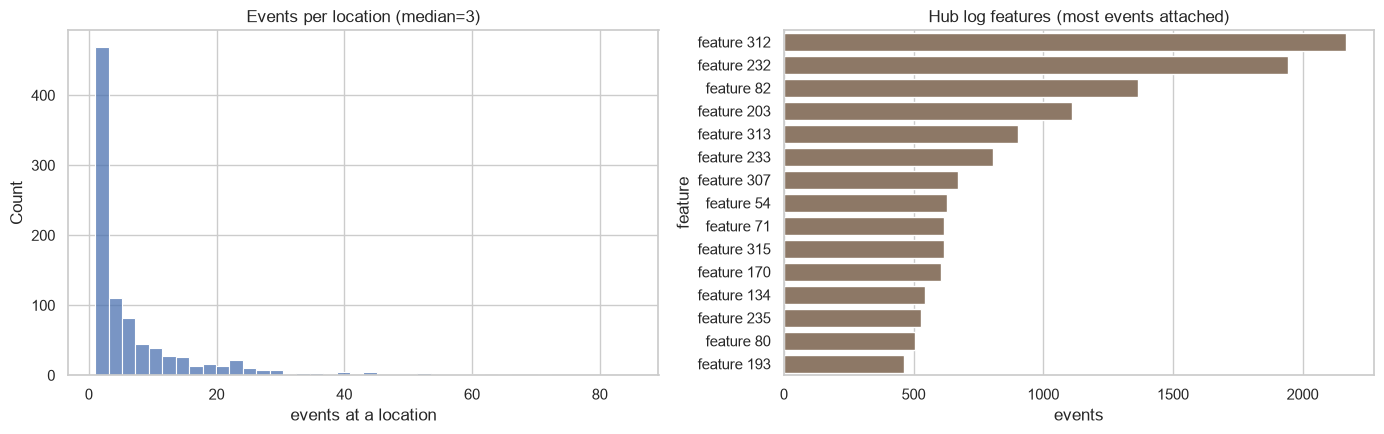

In [9]:
per_loc = graph.run_query_df('''
    MATCH (e:DisruptionEvent)-[:OCCURRED_AT]->(l:Location)
    RETURN l.name AS location, count(*) AS events
''')
hub_feats = graph.run_query_df('''
    MATCH (f:LogFeature)<-[:LOGGED]-(e:DisruptionEvent)
    RETURN f.name AS feature, count(e) AS events
    ORDER BY events DESC LIMIT 15
''')

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(per_loc["events"], bins=40, ax=ax[0], color="#4C72B0")
ax[0].set_title(f"Events per location (median={per_loc.events.median():.0f})")
ax[0].set_xlabel("events at a location")
sns.barplot(data=hub_feats, y="feature", x="events", ax=ax[1], color="#937860")
ax[1].set_title("Hub log features (most events attached)")
plt.tight_layout(); plt.show()
fig.savefig(f"{RENDERINGS_DIR}/events_per_location_and_hub_features.png", dpi=300)

## Does the way faults cascade between sites carry any risk signal?

Faults don't happen in isolation - one site's trouble can be followed by another's. We capture this as a **cascade** between locations (how often an event at one site is followed by an event at another) and score each location by how central it is in that flow. The question that matters for the business case: do the busy cascade hubs also tend to run *hotter* on fault severity? A meaningful relationship here is the justification for adding graph-based features to the model; a weak one is a warning that the cascade may just be restating how busy a site is.

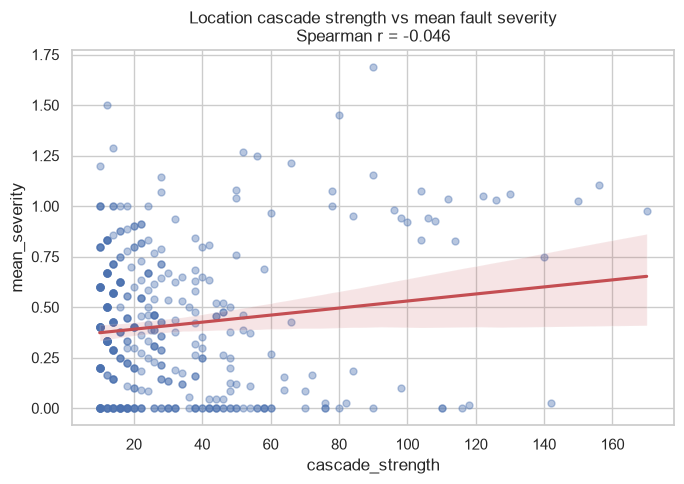

Strongest NEXT_EVENT transitions:


,from_location,to_location,weight
0,location 744,location 734,4
1,location 1107,location 1010,4
2,location 798,location 471,3
3,location 1107,location 126,3
4,location 1008,location 793,3
5,location 931,location 845,3
6,location 653,location 1008,3
7,location 704,location 1107,3
8,location 477,location 124,3
9,location 242,location 122,3


In [10]:
casc = graph.run_query_df('''
    MATCH (l:Location)<-[:OCCURRED_AT]-(e:DisruptionEvent {dataset:'train'})
    WITH l, avg(toFloat(e.fault_severity)) AS mean_severity, count(e) AS n
    WHERE n >= 5
    OPTIONAL MATCH (l)-[o:NEXT_EVENT]->()
    WITH l, mean_severity, n, sum(o.weight) AS out_strength
    OPTIONAL MATCH (l)<-[i:NEXT_EVENT]-()
    WITH l, mean_severity, n, out_strength, sum(i.weight) AS in_strength
    RETURN l.name AS location, mean_severity, n,
           coalesce(out_strength,0) + coalesce(in_strength,0) AS cascade_strength
    ORDER BY cascade_strength DESC
''')

top_edges = graph.run_query_df('''
    MATCH (a:Location)-[r:NEXT_EVENT]->(b:Location)
    RETURN a.name AS from_location, b.name AS to_location, r.weight AS weight
    ORDER BY weight DESC LIMIT 10
''')

corr = casc["cascade_strength"].corr(casc["mean_severity"], method="spearman")
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=casc, x="cascade_strength", y="mean_severity", ax=ax,
            scatter_kws={"alpha": 0.4, "s": 25}, line_kws={"color": "#C44E52"})
ax.set_title(f"Location cascade strength vs mean fault severity\nSpearman r = {corr:.3f}")
plt.tight_layout(); plt.show()
fig.savefig(f"{RENDERINGS_DIR}/cascade_strength_vs_severity.png", dpi=300)
print("Strongest NEXT_EVENT transitions:"); display(top_edges)

## A visual look at one location

Finally, a literal picture of the data: a single busy, fault-prone location, the disruption events that occurred there, and the alarm level of each - a concrete sense of what an individual node in the network looks like.

Visualising location 745


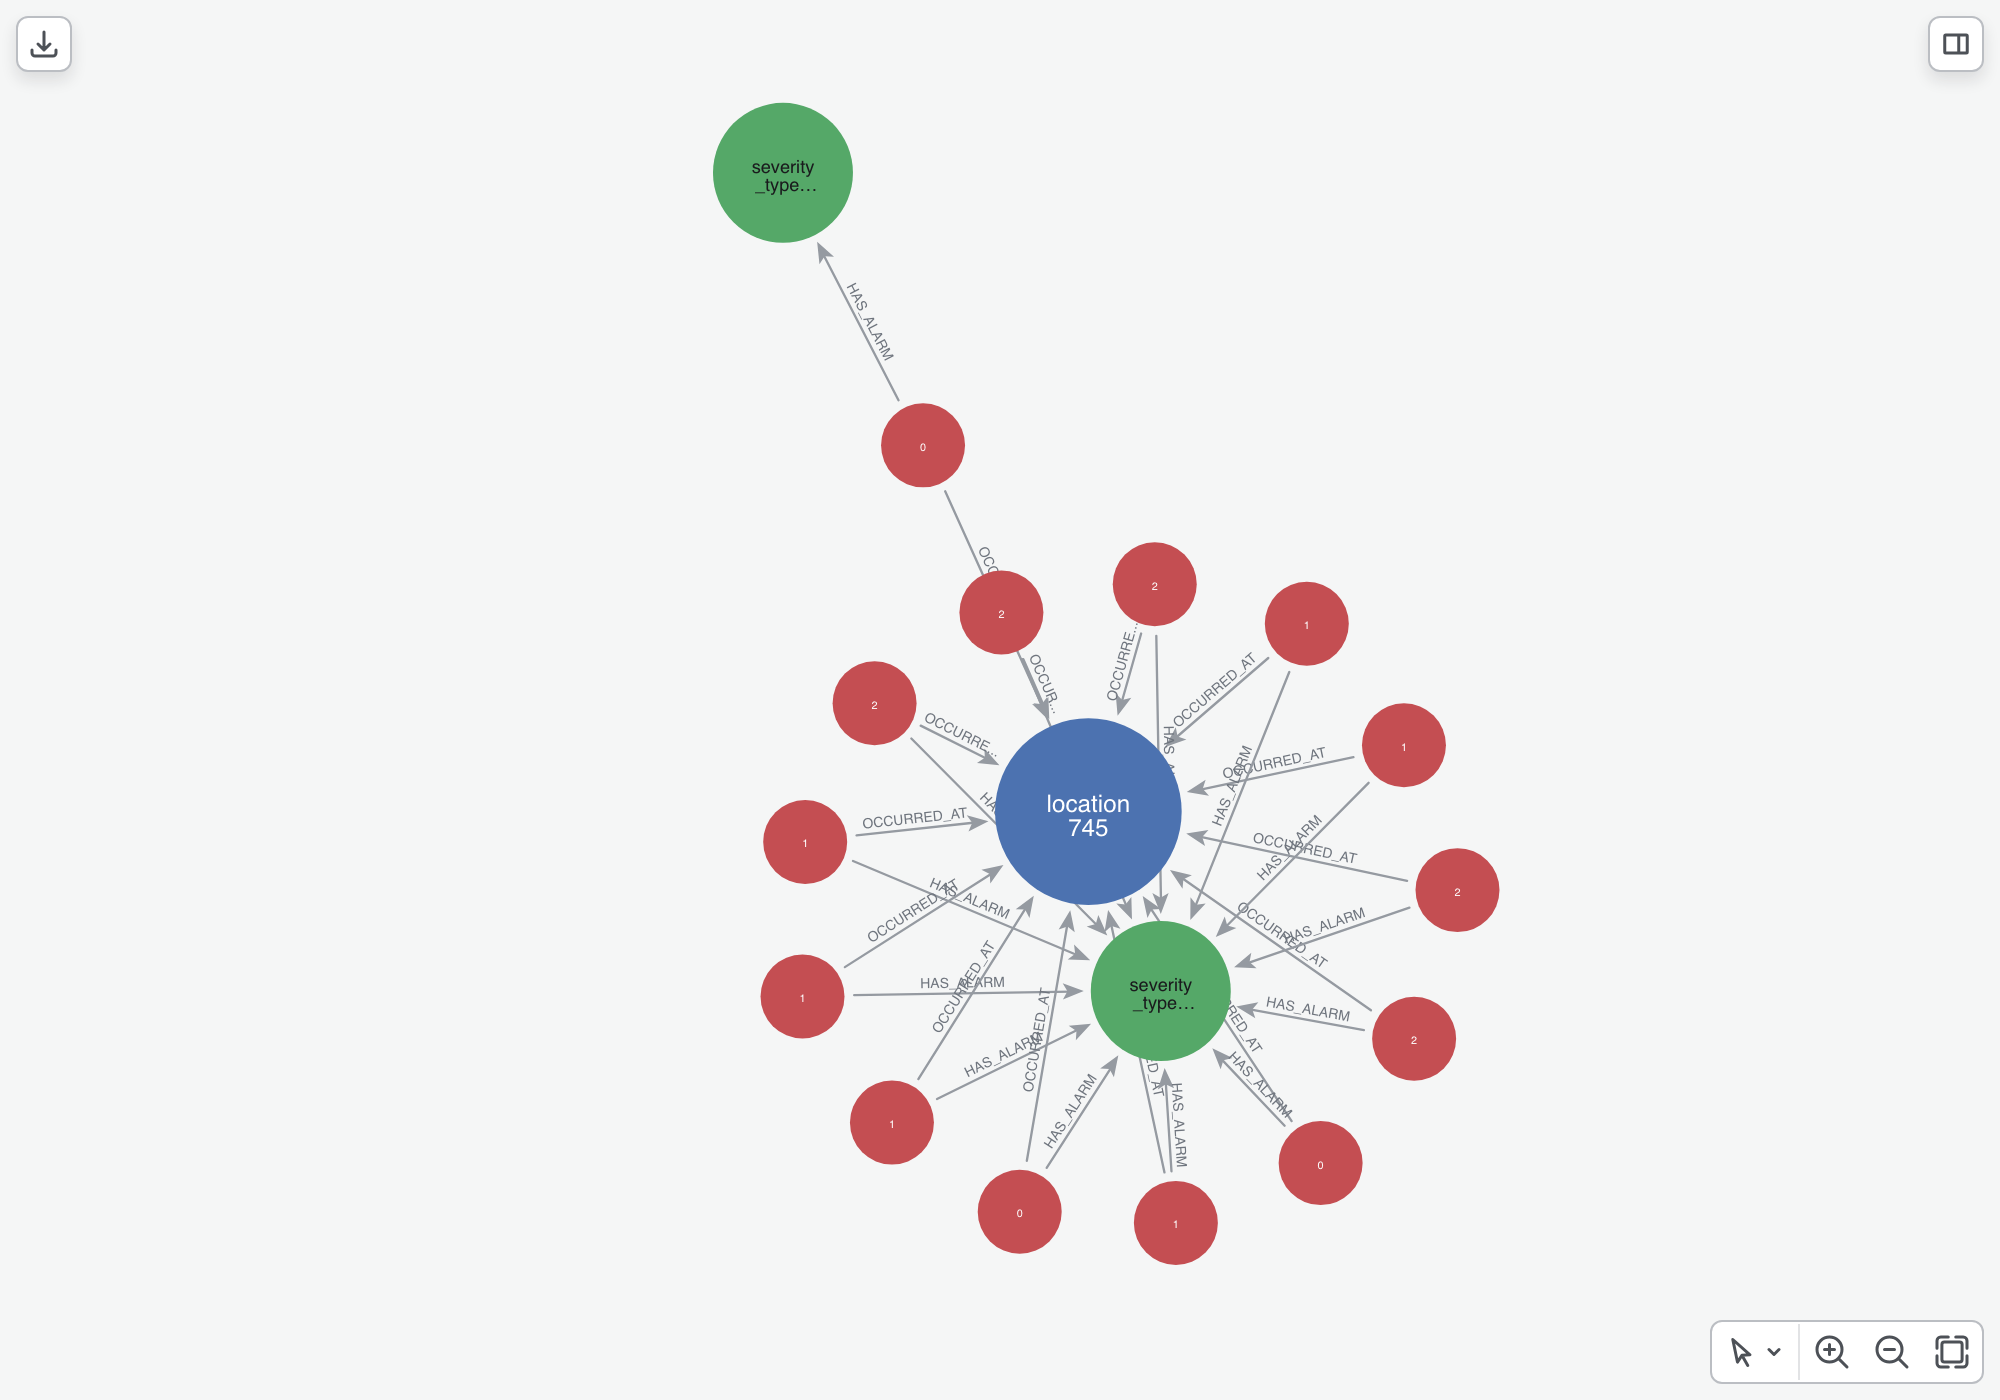

In [11]:
# Pick a busy, fault-prone training location to visualise.
focus = graph.run_query('''
    MATCH (l:Location)<-[:OCCURRED_AT]-(e:DisruptionEvent {dataset:'train'})
    WITH l.name AS name, count(e) AS c,
         sum(CASE WHEN e.fault_severity=2 THEN 1 ELSE 0 END) AS sev2
    WHERE c >= 8 AND c <= 16 AND sev2 >= 1
    RETURN name ORDER BY sev2 DESC, c DESC LIMIT 1
''')[0]["name"]
print("Visualising", focus)

g = graph.run_query_viz('''
    MATCH p=(l:Location {name:$loc})<-[:OCCURRED_AT]-(e:DisruptionEvent)-[:HAS_ALARM]->(s:SeverityType)
    RETURN p
''', {"loc": focus})

VG = from_neo4j(g)
graph.set_caption_by_label(VG, {
    "Location": "name",
    "DisruptionEvent": "fault_severity",
    "SeverityType": "name",
})

# Colour and size nodes by label so the three node types read at a glance.
label_color = {"Location": "#4C72B0", "DisruptionEvent": "#C44E52", "SeverityType": "#55A868"}
label_size = {"Location": 40, "DisruptionEvent": 18, "SeverityType": 30}
for node in VG.nodes:
    lbl = (node.properties.get("labels") or ["?"])[0]
    node.color = label_color.get(lbl, "#999999")
    node.size = label_size.get(lbl, 15)

html = VG.render(layout="forcedirected", height="700px")
await graph.capture_graph_to_png(html, f"{RENDERINGS_DIR}/location_subgraph.png", width=1000, height=700)
Image(f"{RENDERINGS_DIR}/location_subgraph.png")

In [12]:
graph.close()
print("Done - connection closed.")

Done - connection closed.
